In [146]:
import tensorflow as tf

In [147]:
# Data Pre-processing
_URL = 'https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip'

data_path = tf.keras.utils.get_file(origin=_URL,  cache_dir="." ,fname="cat_vs_dogs", extract=True)


In [148]:
from pathlib import Path

data_path = Path(data_path)

data_path = data_path/"cats_and_dogs_filtered"

data_path

train_data = data_path/"train"
val_data = data_path/"validation"

In [ ]:
# Create td.data Dataset
IMAGE_SIZE = (160,160)

train_ds = tf.keras.utils.image_dataset_from_directory(directory=train_data, validation_split=0.2, batch_size=32, subset="training", seed=42, shuffle=True, image_size=IMAGE_SIZE)
val_ds = tf.keras.utils.image_dataset_from_directory(directory=val_data, validation_split=0.2, subset="validation", batch_size=32, seed=42, image_size=IMAGE_SIZE)



In [ ]:

class_names = train_ds.class_names

import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for img,label in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(img[i]/255.0)
        plt.title(class_names[label[i]])
        plt.axis("off")
    



In [ ]:
class_names

In [ ]:
print('Number of validation batches: %d' % tf.data.experimental.cardinality(val_ds))
print('Number of train batches: %d' % tf.data.experimental.cardinality(train_ds))

In [153]:
val_batchs = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batchs // 5)
val_ds = val_ds.skip(val_batchs // 5)


In [ ]:
print('Number of validation batches: %d' % tf.data.experimental.cardinality(val_ds))
print('Number of train batches: %d' % tf.data.experimental.cardinality(train_ds))
print('Number of test batches: %d' % tf.data.experimental.cardinality(test_ds))

In [155]:
## performnce
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


In [156]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2)
])

In [ ]:
data_augmentation

In [ ]:
for image,_ in train_ds.take(1):
    test_img = image[0]

In [ ]:
test_img

In [ ]:
tf.reduce_max(test_img)

In [ ]:
process_inp = tf.keras.applications.mobilenet_v2.preprocess_input


new_img = process_inp(test_img)
new_img

In [ ]:
tf.reduce_min(new_img)

In [163]:
base_model = tf.keras.applications.MobileNetV2(input_shape=(160,160,3), include_top=False)

In [ ]:
base_model.summary()

In [165]:
image_batch, label_batch = next(iter(train_ds))

image_batch.shape

feature_batch = base_model(image_batch)

In [ ]:
feature_batch.shape

In [167]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()

a  =global_average_layer(feature_batch)

In [ ]:
prediction_layer = tf.keras.layers.Dense(1, activation="sigmoid")

prediction_layer(a)

In [169]:
base_model.trainable = False

In [170]:
inputs = tf.keras.Input(shape=(160,160,3))
x = data_augmentation(inputs)
x = process_inp(x)
x = base_model(x, training= False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)

model = tf.keras.Model(inputs, outputs)


In [ ]:
model.summary()

In [ ]:
model.trainable_variables

In [ ]:
tf.keras.utils.plot_model(model, show_shapes=True)


In [174]:
model.compile(loss=tf.keras.losses.BinaryCrossentropy(), optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), metrics=[tf.keras.metrics.BinaryAccuracy(name="bin_accuracy", threshold=0.5)])


In [175]:
model.evaluate(test_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 644ms/step - bin_accuracy: 0.5625 - loss: 0.8455


[0.8454776406288147, 0.5625]

In [176]:
initial_epochs = 10
history  = model.fit(train_ds, validation_data=val_ds, epochs=initial_epochs)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - bin_accuracy: 0.6459 - loss: 0.6325 - val_bin_accuracy: 0.9762 - val_loss: 0.1359
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - bin_accuracy: 0.9071 - loss: 0.2249 - val_bin_accuracy: 0.9881 - val_loss: 0.0868
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - bin_accuracy: 0.9282 - loss: 0.1825 - val_bin_accuracy: 0.9762 - val_loss: 0.0864
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - bin_accuracy: 0.9475 - loss: 0.1418 - val_bin_accuracy: 0.9702 - val_loss: 0.0802
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - bin_accuracy: 0.9459 - loss: 0.1487 - val_bin_accuracy: 0.9762 - val_loss: 0.0746
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - bin_accuracy: 0.9429 - loss: 0.1377 - val_bin_accuracy: 0.9702 - val_loss: 0.0677
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - bin_accuracy: 0.9485 - loss: 0.1258 - val_bin_accuracy: 0.9821 - val_loss: 0.0637
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/s

In [177]:
history.history.keys()

dict_keys(['bin_accuracy', 'loss', 'val_bin_accuracy', 'val_loss'])

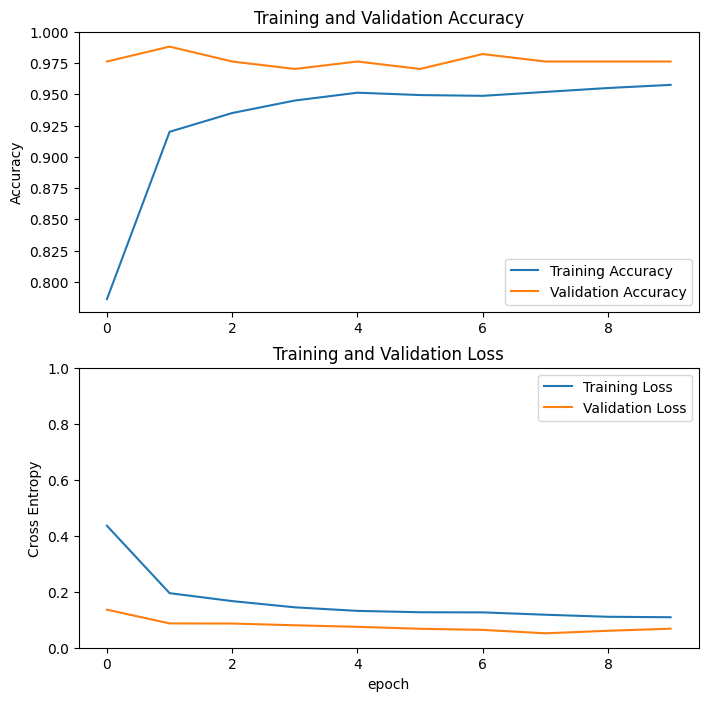

In [193]:

acc = history.history['bin_accuracy']
val_acc = history.history['val_bin_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()


In [179]:
len(base_model.layers)

154

In [180]:
for layer in base_model.layers[:100]:
    print(layer)

<InputLayer name=input_layer_9, built=True>
<Conv2D name=Conv1, built=True>
<BatchNormalization name=bn_Conv1, built=True>
<ReLU name=Conv1_relu, built=True>
<DepthwiseConv2D name=expanded_conv_depthwise, built=True>
<BatchNormalization name=expanded_conv_depthwise_BN, built=True>
<ReLU name=expanded_conv_depthwise_relu, built=True>
<Conv2D name=expanded_conv_project, built=True>
<BatchNormalization name=expanded_conv_project_BN, built=True>
<Conv2D name=block_1_expand, built=True>
<BatchNormalization name=block_1_expand_BN, built=True>
<ReLU name=block_1_expand_relu, built=True>
<ZeroPadding2D name=block_1_pad, built=True>
<DepthwiseConv2D name=block_1_depthwise, built=True>
<BatchNormalization name=block_1_depthwise_BN, built=True>
<ReLU name=block_1_depthwise_relu, built=True>
<Conv2D name=block_1_project, built=True>
<BatchNormalization name=block_1_project_BN, built=True>
<Conv2D name=block_2_expand, built=True>
<BatchNormalization name=block_2_expand_BN, built=True>
<ReLU name=bl

## Fine-Tune

In [186]:
base_model.trainable = True

In [187]:
len(base_model.layers)

154

In [188]:
fine_tune_at = 100 # this layer onwards

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False


In [189]:
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_3 (TrueDivide)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_3 (Subtract)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,829 (8.63 MB)

 Trainable params: 1,862,721 (7.11 MB)

 Non-trainable params: 396,544 (1.51 MB)

 Optimizer params: 2,564 (10.02 KB)

In [190]:
len(model.trainable_variables)

56

In [191]:
fine_tune_epochs = 10
total_epochs =  initial_epochs + fine_tune_epochs

history_fine = model.fit(train_ds,
                         epochs=total_epochs,
                         initial_epoch=len(history.epoch),
                         validation_data=val_ds)

Epoch 11/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - bin_accuracy: 0.9540 - loss: 0.1181 - val_bin_accuracy: 0.9643 - val_loss: 0.0664
Epoch 12/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - bin_accuracy: 0.9478 - loss: 0.1175 - val_bin_accuracy: 0.9702 - val_loss: 0.0629
Epoch 13/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - bin_accuracy: 0.9563 - loss: 0.1204 - val_bin_accuracy: 0.9583 - val_loss: 0.0723
Epoch 14/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - bin_accuracy: 0.9542 - loss: 0.1153 - val_bin_accuracy: 0.9524 - val_loss: 0.0787
Epoch 15/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - bin_accuracy: 0.9516 - loss: 0.1144 - val_bin_accuracy: 0.9524 - val_loss: 0.0913
Epoch 16/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - bin_accuracy: 0.9618 - loss: 0.0933 - val_bin_accuracy: 0.9524 - val_loss: 0.0805
Epoch 17/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - bin_accuracy: 0.9669 - loss: 0.0852 - val_bin_accuracy: 0.9702 - val_loss: 0.0616
Epoch 18/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s

In [196]:
acc += history_fine.history['bin_accuracy']
val_acc += history_fine.history['val_bin_accuracy']

loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

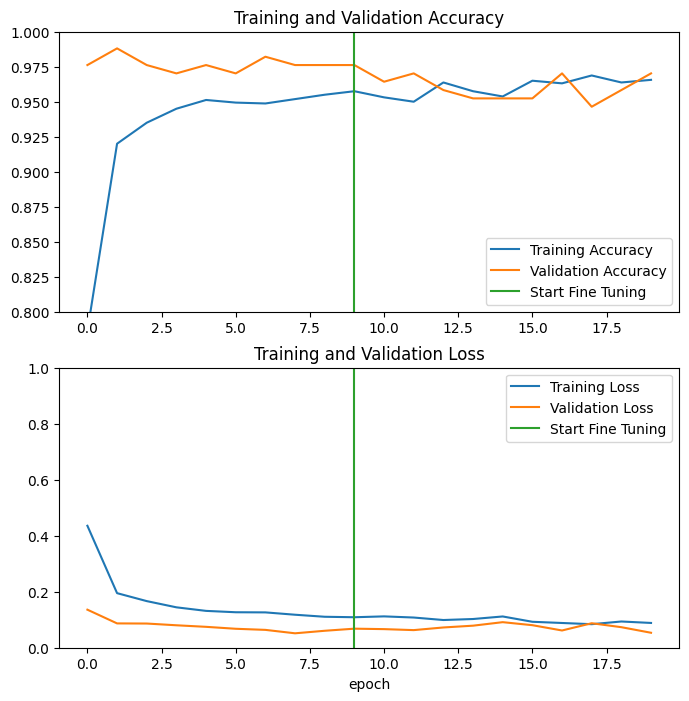

In [197]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0.8, 1])
plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs-1,initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()